In [ ]:
!pip install gymnasium[classic-control] torch numpy matplotlib -q

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

In [ ]:
#THE Q NETWORK
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

Replay Buffer


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (np.array(state), action, reward, np.array(next_state), done)

    def __len__(self):
        return len(self.buffer)

DQN agent setup

In [ ]:
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
buffer = ReplayBuffer()

gamma = 0.99
batch_size = 64
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
target_update_freq = 10

Action selection

In [ ]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    with torch.no_grad():
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = policy_net(state_t)
        return q_values.argmax().item()

Training setup

In [ ]:
def train_step():
    if len(buffer) < batch_size:
        return

    states, actions, rewards, next_states, dones = buffer.sample(batch_size)

    states = torch.FloatTensor(states).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    q_values = policy_net(states).gather(1, actions)
    with torch.no_grad():
        max_next_q = target_net(next_states).max(1, keepdim=True)[0]
        target_q = rewards + gamma * max_next_q * (1 - dones)

    loss = nn.MSELoss()(q_values, target_q)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Main training Loop

In [ ]:
num_episodes = 300
reward_history = []

for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        buffer.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        train_step()

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    reward_history.append(total_reward)

    if episode % 20 == 0:
        avg_reward = np.mean(reward_history[-20:])
        print(f"Episode {episode}, Reward: {total_reward}, Avg(last 20): {avg_reward:.1f}, Epsilon: {epsilon:.3f}")

Episode 0, Reward: 59.0, Avg(last 20): 59.0, Epsilon: 0.491
Episode 20, Reward: 20.0, Avg(last 20): 62.3, Epsilon: 0.444
Episode 40, Reward: 13.0, Avg(last 20): 86.2, Epsilon: 0.402
Episode 60, Reward: 93.0, Avg(last 20): 77.8, Epsilon: 0.363
Episode 80, Reward: 166.0, Avg(last 20): 101.5, Epsilon: 0.329
Episode 100, Reward: 112.0, Avg(last 20): 110.2, Epsilon: 0.297
Episode 120, Reward: 52.0, Avg(last 20): 184.8, Epsilon: 0.269
Episode 140, Reward: 372.0, Avg(last 20): 207.3, Epsilon: 0.243
Episode 160, Reward: 185.0, Avg(last 20): 164.5, Epsilon: 0.220
Episode 180, Reward: 42.0, Avg(last 20): 281.4, Epsilon: 0.199
Episode 200, Reward: 224.0, Avg(last 20): 368.1, Epsilon: 0.180
Episode 220, Reward: 46.0, Avg(last 20): 225.0, Epsilon: 0.163
Episode 240, Reward: 126.0, Avg(last 20): 129.2, Epsilon: 0.147
Episode 260, Reward: 109.0, Avg(last 20): 97.5, Epsilon: 0.133
Episode 280, Reward: 120.0, Avg(last 20): 105.5, Epsilon: 0.121


In [ ]:
#plot results

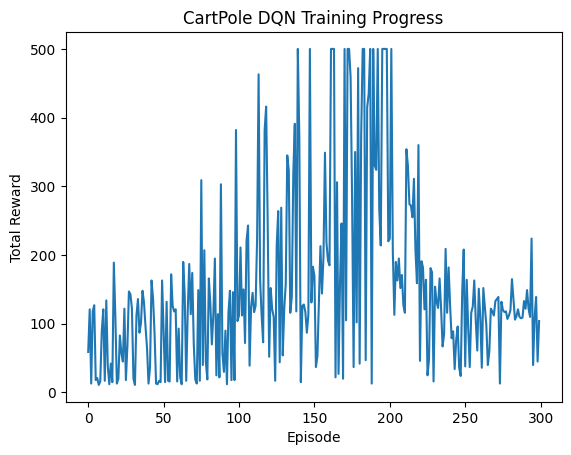

In [ ]:
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("CartPole DQN Training Progress")
plt.show()

Plot results

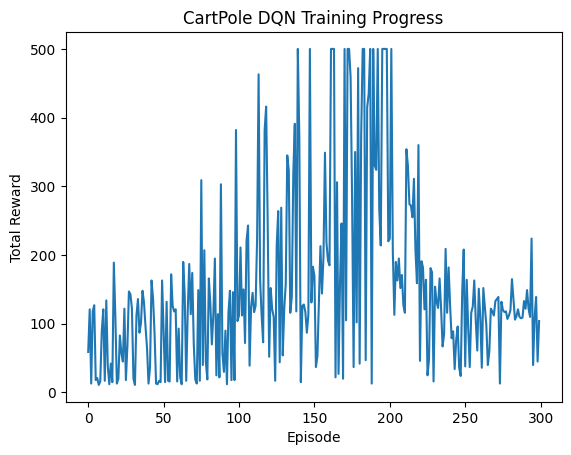

In [ ]:
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("CartPole DQN Training Progress")
plt.show()

test the trained agent

In [ ]:
def test_agent(episodes=5):
    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(state_t).argmax().item()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
        print(f"Test Episode {ep+1}: Reward = {total_reward}")

test_agent()

Test Episode 1: Reward = 111.0
Test Episode 2: Reward = 102.0
Test Episode 3: Reward = 106.0
Test Episode 4: Reward = 114.0
Test Episode 5: Reward = 107.0


baseline comparision agent


In [ ]:
def random_agent_baseline(episodes=5):
    rewards = []
    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total = 0
        while not done:
            action = env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
        rewards.append(total)
    print(f"Random agent avg reward: {np.mean(rewards):.1f}")
    return rewards

random_rewards = random_agent_baseline()

Random agent avg reward: 20.2


## Conclusion
The DQN agent improved from a random baseline of ~20 average reward
to ~100+ average reward after 300 training episodes, demonstrating
successful learning of the CartPole balancing task.